In [27]:
import glob                                                                                                
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

files = glob.glob("data/scrap-pagebogota-*.csv")                       
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

## 1. Data Overview                                                                                        

- The dataset comprises approximately 70,000 residential property listings from Bogotá, each described by 26 features including area (m²), number of bedrooms, socioeconomic stratum, parking availability, and listing price, among others.                                            
                
- The goal of this section is to perform an exploratory data analysis (EDA) to understand the structure, quality, and distribution of the data — including location-based features such as Points of Interest (POIs) — before proceeding to feature engineering and modeling.

In [28]:
df.columns

Index(['id', 'area_m2', 'cuartos', 'estrato', 'tipo', 'parqueaderos', 'banios',
       'piso', 'precio', 'precio_m2', 'precio_admin', 'vendedor',
       'tipo_vendedor', 'tipo_propiedad', 'barrio', 'ciudad', 'lat', 'lon',
       'direccion', 'id_propiedad', 'creado', 'publicado', 'actualizado',
       'antiguedad', 'descripcion', 'url'],
      dtype='object')

## 2.1 Area (m²) — Outlier Treatment                                                                       

According to CAMACOL's Economic Report No. 121 *(Internacionalización de la Vivienda,CAMACOL, 2024)*, the median area of sold residential units in Bogotá ranges between 60–70 m². In light of this, values above 5,000 m² were identified as outliers (~200 rows) and truncated, as they likely represent data entry errors or non-residential listings rather than typical housing stock.                                                                         
                                                                                                             
> Source: [Informe Económico No. 121 — CAMACOL](https://camacol.co/sites/default/files/descargables/Informe%20Econ%C3%B3mico%20121.pdf)

Colombian urban regulation establishes a minimum habitable area of 18 m² for residential units (non-VIS/VIP housing category). Listings below this threshold were removed from the dataset as they do not represent valid residential units.                                                  
                  
> Source: [Decreto 462 de 2024 — Alcaldía de Bogotá](https://www.alcaldiabogota.gov.co/sisjur/normas/Norma1.jsp?i=139499)

In [29]:
df = df[(df['area_m2'] >= 18) & (df['area_m2'] <= 5000)]

## 3. Feature Selection — Dropping Irrelevant Columns

The following columns are dropped prior to modeling:                                                       
   
- **`vendedor` / `tipo_vendedor`** — broker identity and type carry no predictive signal for price; they introduce noise and potential data leakage.
- **`tipo`** — contains only `venta` across all records (single-value column), adding no information.
- **`creado`, `publicado`, `actualizado`** — internal timestamps from the data source, not properties of the unit itself.
- **`url`** — listing identifier with no predictive value.

In [30]:
df = df.drop(columns=['id','vendedor', 'tipo_vendedor','id_propiedad','creado','publicado','actualizado','url','tipo'])

## 4. Property Type — Recategorization                                                                     
                                                                                                             
The `tipo_propiedad` column contains 11 distinct categories in the raw data (casa,apartamento, apartaestudio, oficina, lote, bodega, etc.). For this analysis, we restrict the dataset to residential units only, excluding commercial and non-standard listings.                     
                                                                                                            
Units categorized as `apartaestudio` (essentially a studio/loft) are recategorized as `apartamento`, as they share the same structural characteristics. This yields two final classes: **house** and **apartment**.                                                                      
                                                                                                            
This decision is also consistent with the properties microservice domain model, which enforces a `PropertyType` enum with exactly two values (`house`, `apartment`), ensuring alignment between the training data distribution and the production system's data contract.

In [31]:
df['tipo_propiedad'].unique()

array(['apartamento', 'casa', 'apartaestudio', 'oficina', 'consultorio',
       'local', 'habitacion', 'casa lote', 'lote', 'casa campestre',
       'bodega', 'finca', 'edificio', 'cabaña'], dtype=object)

In [32]:
correcciones = {
    'apartaestudio': 'apartamento',                                                                        
    'casa lote': 'casa',
    'casa campestre': 'casa',                                                                              
    'cabaña': 'casa',
}                                                                                                          
                                                                                                             
df['tipo_propiedad'] = df['tipo_propiedad'].replace(correcciones)
df = df[df['tipo_propiedad'].isin(['apartamento', 'casa'])]

<Axes: xlabel='tipo_propiedad', ylabel='count'>

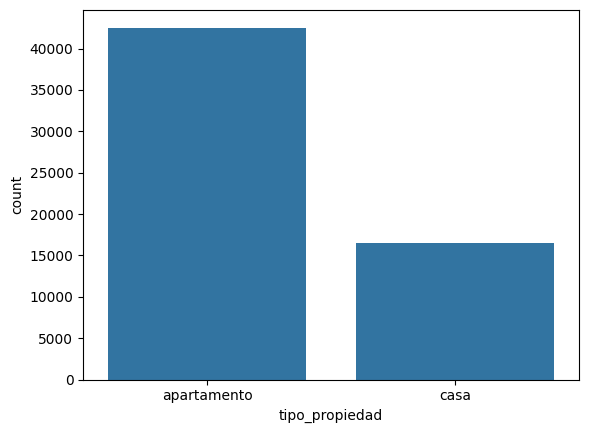

In [33]:
sns.countplot(df, x="tipo_propiedad")

(0.0, 500.0)

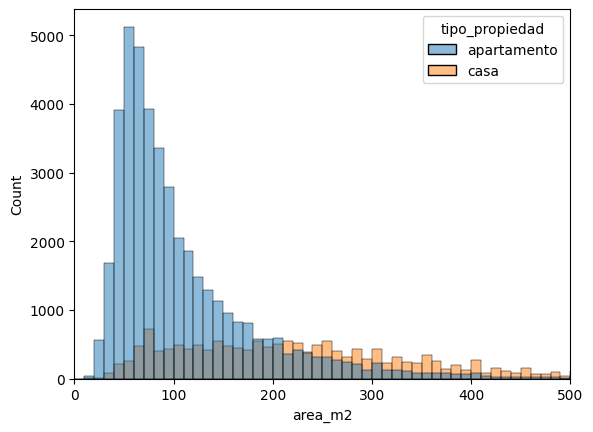

In [34]:
sns.histplot(data=df, x="area_m2", bins=100, binrange=(0, 1000), hue='tipo_propiedad')
plt.xlim(0, 500)

The dataset is heavily skewed towards apartment listings, which reflects the actual residential landscape of Bogotá — a densely urbanized city where multi-family buildings dominate, particularly in consolidated neighborhoods.                                                      
                                                                                                            
Regarding area, the majority of residential units fall below 100 m², which is consistent with the CAMACOL benchmark discussed in section 2.1. Apartments typically concentrate within this range by design, while houses may exceed it due to multi-floor configurations that accumulate total built area across levels.

In [35]:
df

,area_m2,cuartos,estrato,parqueaderos,banios,piso,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion
0,44,2,3,Sin especificar,2,1°,145000000,3295454.55,113000.0,apartamento,ismael-perdomo,bogota,4.586188,-74.161307,Torres de Bellavista,1 a 8 años,Apartamento totalmente terminado ubicado en el...
1,41,2,2,Sin especificar,1,1°,103000000,2512195.12,60000.0,apartamento,parcela-el-porvenir,bogota,4.643511,-74.186697,Cra. 100 #50b-45,9 a 15 años,Apartamento ubicado en el Conjunto Senderos de...
2,60,3,3,Sin especificar,2,Sin especificar,175000000,2916666.67,148800.0,apartamento,turingia-et.-ii,bogota,4.749566,-74.089924,Carrera 101 #151-33,9 a 15 años,"NHI-VENDE APARTAMENTO EN SUBA LA CAMPIÑA, en c..."
3,45,2,2,Sin especificar,1,4°,120000000,2666666.67,0.0,apartamento,bosa-el-recreo,bogota,4.626595,-74.203657,Okapi 2,9 a 15 años,Apartamento 4 piso \nArea 45m2\n2 habitaciones...
4,53,2,3,Sin especificar,1,4°,140000000,2641509.43,120000.0,apartamento,el-tabor,bogota,4.727849,-74.087067,CRA 89 130D 80,16 a 30 años,OPORTUNIDAD!! APARTAMENTO 2 HABITACIONES AMPLI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69612,440,6,5,6,5,2°,2400000000,5454545.45,0.0,casa,pasadena,bogota,4.688324,-74.059257,Calle 101A # 47 - 12,más de 30 años,"Lindísima, esquinera de dos plantas, totalment..."
69614,1000,5,6,Más de 10,5,Sin especificar,2500000000,2500000.00,1000000.0,casa,torca-rural-i,bogota,4.807562,-74.022017,CL 235 # 2,9 a 15 años,hermosa casa en torca floresta de la sabana co...
69617,350,3,6,5,4,2°,2300000000,6571428.57,0.0,apartamento,la-cabrera,bogota,4.666381,-74.049118,Cra. 9 con 85,16 a 30 años,Para venta apartamento La CabreraCra. 9 con 85...
69618,266,5,5,4,6,Sin especificar,2350000000,8834586.47,0.0,apartamento,la-calleja,bogota,4.712728,-74.049004,Calle 128b #19-55,sin especificar,¡SE VENDE HERMOSO APARTAMENTO REMODELADO Hermo...


In [36]:
df.banios.unique()

array(['2', '1', 'Sin especificar', '3', '4', '5', '6', '8', '10', '7',
       '9'], dtype=object)

In [43]:
df[df['estrato']=='especificar']

,area_m2,cuartos,estrato,parqueaderos,banios,piso,precio,precio_m2,precio_admin,tipo_propiedad,barrio,ciudad,lat,lon,direccion,antiguedad,descripcion
13599,422,5,especificar,3,4.0,1°,1950000000,4620853.08,0.0,casa,el-contador,bogota,4.721472,-74.043345,calle 140 #16a - 38,más de 30 años,Te invitamos a conocer este maravilloso predio...
14200,344,6,especificar,Sin especificar,6.0,2°,1745000000,5072674.42,0.0,casa,la-castellana,bogota,4.682957,-74.058881,Carrera 45A # 94 - 87,más de 30 años,Se vende casa de dos pisos adecuada para ofici...
16249,366,9,especificar,8,4.0,3°,1595000000,4357923.50,0.0,casa,santa-barbara-central,bogota,4.697416,-74.039724,Carrera 13 # 118-20,más de 30 años,EXCELENTE CASA CON USO COMERCIAL EN MAGNIFICA ...
21053,390,0,especificar,Sin especificar,10.0,3°,4000000000,10256410.26,0.0,casa,teusaquillo,bogota,4.622304,-74.069823,Avenoda caracas # 33 a 11,más de 30 años,USO COMERCIAL E INSTITUCIONAL\n\nDESCRIPCIÓN I...
30268,33,0,especificar,1,1.0,Sin especificar,310000000,9393939.39,374000.0,apartamento,portales-del-norte,bogota,4.751930,-74.064222,CR 67 167 61 BOGOTA OF 602 URB CENTRO EMPRESAR...,16 a 30 años,Inmobiliaria en bogota vende amplia oficina en...
30687,35,1,especificar,1,1.0,3°,350000000,10000000.00,0.0,apartamento,chico-norte,bogota,4.683918,-74.047436,KR 14 99 33 OF 312,sin especificar,VENDO magnifica oficina sobre la calle 100 a p...
35056,384,6,especificar,3,5.0,Sin especificar,950000000,2473958.33,0.0,casa,la-paz,bogota,4.657205,-74.074454,Calle 64 # 27A - 51,más de 30 años,Gran oportunidad para inversionistas. Ubicado ...
43012,348,5,especificar,1,4.0,2°,1096000000,3149425.29,0.0,casa,ciudad-universitaria,bogota,4.632085,-74.082652,Cra 34A #29A-26,más de 30 años,Esta casa tradicional tiene su vista hacia el ...


In [41]:
df["banios"] = pd.to_numeric(df["banios"], errors="coerce")
df.groupby(["estrato", "tipo_propiedad"]).agg({"banios": "median"})

banios
estrato     tipo_propiedad        
0           apartamento        2.0
            casa               3.0
1           apartamento        1.0
            casa               3.0
2           apartamento        1.0
            casa               3.0
3           apartamento        2.0
            casa               3.0
4           apartamento        2.0
            casa               3.0
5           apartamento        3.0
            casa               4.0
6           apartamento        3.0
            casa               5.0
especificar apartamento        1.0
            casa               4.5

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'especificar'

<Figure size 800x600 with 0 Axes>